## 2. Import Required Libraries

In [2]:
# EDA tools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(10)
import warnings
warnings.filterwarnings("ignore")

#Single model classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Ensemble classifications models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Model evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics._scorer import _SCORERS
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report, roc_auc_score,f1_score, recall_score, precision_score, average_precision_score,
make_scorer, precision_recall_curve)
from sklearn.utils.class_weight import compute_sample_weight
import time

# Imbalance, Hyperparameter tunning and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


## 3. Exploratory Data Analysis


In [3]:
#Load the file into a pandas data frame.
data = pd.read_csv("diabetes.csv")
#Get structural information of the data set.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
#Visualize first 5 rows of data of the first 12 columns.
data.head().iloc[:,:12]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN


In [5]:
#Visualize first 5 rows of data of the remaining columns.
data.head().iloc[:,12:]

,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,41,0,1,0,0,0,250.83,NaN,NaN,1,...,No,No,No,No,No,No,No,No,No,NO
1,59,0,18,0,0,0,276,250.01,255,9,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,11,5,13,2,0,1,648,250,V27,6,...,No,No,No,No,No,No,No,No,Yes,NO
3,44,1,16,0,0,0,8,250.43,403,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,51,0,8,0,0,0,197,157,250,5,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
#Look for missing values.
data.isna().any()

encounter_id                False
patient_nbr                 False
race                         True
gender                      False
age                         False
weight                       True
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
payer_code                   True
medical_specialty            True
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                       True
diag_2                       True
diag_3                       True
number_diagnoses            False
max_glu_serum                True
A1Cresult                    True
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide 

In [7]:
#Do data preprocessing on missing values
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
data = data.drop(columns=cols_to_drop)
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
# Remove columns with only one unique value
data = data.drop(columns=['citoglipton', 'examide'])
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
#For the "race" column, which is a categorical feature and already includes an "Other" category, we will assign all missing values to "Other"
data['race'] = data['race'].fillna('Other')

In [10]:
def icd9_to_numeric(icd_code):
    if pd.isna(icd_code) or icd_code == 'Unknown':
        return 0
    code_str = str(icd_code)
    if code_str.startswith('E') or code_str.startswith('V'):
        return 1000
    try:
        # Keep only the integer part before decimal point
        return int(float(code_str))
    except:
        return 0 

# Process three diagnosis features
data['diag_1_numeric'] = data['diag_1'].apply(icd9_to_numeric)
data['diag_2_numeric'] = data['diag_2'].apply(icd9_to_numeric)
data['diag_3_numeric'] = data['diag_3'].apply(icd9_to_numeric)

# Delete diag_1, diag_2, diag_3 columns
data = data.drop(columns=['diag_1', 'diag_2', 'diag_3'])
data.head()

# Rename diag_1_numeric, diag_2_numeric, diag_3_numeric columns to diag_1, diag_2, diag_3
data = data.rename(columns={'diag_1_numeric': 'diag_1', 'diag_2_numeric': 'diag_2', 'diag_3_numeric': 'diag_3'})
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,NO,250,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,No,No,Ch,Yes,>30,276,250,255
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,Yes,NO,648,250,1000
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,No,No,Ch,Yes,NO,8,250,403
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,No,No,Ch,Yes,NO,197,157,250


In [11]:
def age_to_mid(age_str):
    # age_str is in the format "[20-30)"
    if isinstance(age_str, str) and '-' in age_str:
        nums = age_str.replace('[','').replace(')','').split('-')
        return (int(nums[0]) + int(nums[1])) // 2
    else:
        return None

data['age'] = data['age'].apply(age_to_mid)
data['age'].head()

0     5
1    15
2    25
3    35
4    45
Name: age, dtype: int64

In [12]:
data['readmitted'] = data['readmitted'].apply(lambda x: 'YES' if x == '<30' else 'NO')
data['readmitted'].value_counts()

readmitted
NO     90409
YES    11357
Name: count, dtype: int64

In [13]:
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
] # exclude 'citoglipton' and 'examide' for they had been removed

# count the total number of medications used by each patient (as long as it's not "No", it's considered used)
data['num_drugs'] = data[drug_columns].apply(lambda row: sum(row != 'No'), axis=1)

In [14]:
# Create combined feature: admission_type_source
def create_admission_combination(row):
    admission_type = row['admission_type_id']
    admission_source = row['admission_source_id']
    
    # Combinations based on business logic
    if admission_type == 1 and admission_source == 7:  # Emergency + ER
        return 'Emergency_ER'
    elif admission_type == 2 and admission_source == 1:  # Urgent + Physician
        return 'Urgent_Physician'
    elif admission_type == 3 and admission_source == 1:  # Elective + Physician
        return 'Elective_Physician'
    elif admission_type == 2 and admission_source == 7:  # Urgent + ER
        return 'Urgent_ER'
    else:
        return 'Other_Combination'

# Apply combined feature
data['admission_type_source'] = data.apply(create_admission_combination, axis=1)

# Delete original two columns
data.drop(['admission_type_id', 'admission_source_id'], axis=1, inplace=True)

data.head()

,encounter_id,patient_nbr,race,gender,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3,num_drugs,admission_type_source
0,2278392,8222157,Caucasian,Female,5,25,1,41,0,1,...,No,No,No,No,NO,250,0,0,0,Other_Combination
1,149190,55629189,Caucasian,Female,15,1,3,59,0,18,...,No,No,Ch,Yes,NO,276,250,255,1,Emergency_ER
2,64410,86047875,AfricanAmerican,Female,25,1,2,11,5,13,...,No,No,No,Yes,NO,648,250,1000,1,Emergency_ER
3,500364,82442376,Caucasian,Male,35,1,2,44,1,16,...,No,No,Ch,Yes,NO,8,250,403,1,Emergency_ER
4,16680,42519267,Caucasian,Male,45,1,1,51,0,8,...,No,No,Ch,Yes,NO,197,157,250,2,Emergency_ER


In [15]:
#drop encounter_id	patient_nbr	 columns. Not relevant

data.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

In [16]:
data.describe().iloc[:,:12]

,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,diag_1,diag_2
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,65.967022,3.715642,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,501.629130,451.103060
std,15.940838,5.280166,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,214.898338,198.686789
min,5.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,55.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,410.000000,276.000000
50%,65.000000,1.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,441.000000,427.000000
75%,75.000000,4.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,599.000000,569.000000
max,95.000000,28.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1000.000000,1000.000000


In [17]:
data.describe().iloc[:,12:]

,diag_3,num_drugs
count,101766.000000,101766.000000
mean,441.231168,1.179706
std,219.514279,0.920190
min,0.000000,0.000000
25%,274.000000,1.000000
50%,411.000000,1.000000
75%,535.000000,2.000000
max,1000.000000,6.000000


In [18]:
#Get number of unique values for each discrete variable in the dataset.
for col in data.describe().columns:
    if data[col].dtype == int:
        print(f'{col}:', data[col].nunique())

age: 10
discharge_disposition_id: 26
time_in_hospital: 14
num_lab_procedures: 118
num_procedures: 7
num_medications: 75
number_outpatient: 39
number_emergency: 33
number_inpatient: 21
number_diagnoses: 16
diag_1: 666
diag_2: 619
diag_3: 640
num_drugs: 7


In [19]:
#Get value counts for SpecialDay
data.readmitted.value_counts()

readmitted
NO     90409
YES    11357
Name: count, dtype: int64

In [20]:
#Get non-numerical features.
non_num_cols = list(set(data.columns) - set(data.describe().columns))
print('Non-numerical features: ',non_num_cols)

Non-numerical features:  ['readmitted', 'gender', 'glimepiride', 'tolbutamide', 'repaglinide', 'chlorpropamide', 'acarbose', 'glyburide', 'glipizide-metformin', 'glipizide', 'nateglinide', 'pioglitazone', 'rosiglitazone', 'metformin-pioglitazone', 'glyburide-metformin', 'admission_type_source', 'troglitazone', 'metformin', 'tolazamide', 'race', 'change', 'diabetesMed', 'glimepiride-pioglitazone', 'insulin', 'acetohexamide', 'metformin-rosiglitazone', 'miglitol']


In [21]:
#Get numerical features.
num_cols = list(set(data.describe().columns))
print('Numerical features: ', num_cols)

Numerical features:  ['diag_1', 'diag_2', 'number_emergency', 'num_procedures', 'num_lab_procedures', 'number_inpatient', 'discharge_disposition_id', 'age', 'num_drugs', 'time_in_hospital', 'diag_3', 'num_medications', 'number_outpatient', 'number_diagnoses']


In [22]:
#remove irrelevant identifiers


#### 4.1 One-hot-code categorical features

In [23]:
#Create list with categorical features' names.
#data.readmitted[data.readmitted =='>30'] = 2
data.readmitted[data.readmitted =='YES'] = 1
data.readmitted[data.readmitted =='NO'] = 0

target = data.readmitted.copy()
non_num_cols.remove('readmitted')
data = data.drop(columns= ['readmitted'])
nonum_feats_names = non_num_cols

#Create list with numerical features' names.
num_cols_names = num_cols

In [24]:
#Assign appropriate data type to categorical variables.
nonum_feats = data[nonum_feats_names].astype('category')
nonum_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   gender                    101766 non-null  category
 1   glimepiride               101766 non-null  category
 2   tolbutamide               101766 non-null  category
 3   repaglinide               101766 non-null  category
 4   chlorpropamide            101766 non-null  category
 5   acarbose                  101766 non-null  category
 6   glyburide                 101766 non-null  category
 7   glipizide-metformin       101766 non-null  category
 8   glipizide                 101766 non-null  category
 9   nateglinide               101766 non-null  category
 10  pioglitazone              101766 non-null  category
 11  rosiglitazone             101766 non-null  category
 12  metformin-pioglitazone    101766 non-null  category
 13  glyburide-metformin       101

In [25]:
#One-hot-code categorical variables and dropping the reference value.
ohc_feats = pd.get_dummies(nonum_feats,drop_first=True)
ohc_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 60 columns):
 #   Column                                   Non-Null Count   Dtype
---  ------                                   --------------   -----
 0   gender_Male                              101766 non-null  bool 
 1   gender_Unknown/Invalid                   101766 non-null  bool 
 2   glimepiride_No                           101766 non-null  bool 
 3   glimepiride_Steady                       101766 non-null  bool 
 4   glimepiride_Up                           101766 non-null  bool 
 5   tolbutamide_Steady                       101766 non-null  bool 
 6   repaglinide_No                           101766 non-null  bool 
 7   repaglinide_Steady                       101766 non-null  bool 
 8   repaglinide_Up                           101766 non-null  bool 
 9   chlorpropamide_No                        101766 non-null  bool 
 10  chlorpropamide_Steady                    101766 non-null



### 4.2 Plain Vanilla Classification Models

The classifiers that I will be testing are:
* Logistic Regression
+ Decision Tree
* Random Forest
* Gradient Boosting

In [26]:
ohc_data = pd.concat([data[num_cols_names], ohc_feats],axis=1)
ohc_data = ohc_data.apply(pd.to_numeric)
target = target.apply(pd.to_numeric)
#results1 = baseline_models(data=[ohc_data,target], verbose=True)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(ohc_data, target, test_size = 0.25, random_state = 42)


In [28]:
from sklearn.utils.validation import column_or_1d
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     22593
           1       0.17      0.51      0.25      2849

    accuracy                           0.66     25442
   macro avg       0.54      0.60      0.52     25442
weighted avg       0.83      0.66      0.72     25442



In [30]:
#ordinal_encoder = ce.OrdinalEncoder()
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     22593
           1       0.53      0.01      0.01      2849

    accuracy                           0.89     25442
   macro avg       0.71      0.50      0.48     25442
weighted avg       0.85      0.89      0.84     25442



The Gradient Boosting Classifier is the best performing so far. Being this a binary classification problem with an imbalanced dataset, I am mostly concerned with the f1 and roc_auc scores. The f1 score is the harmonic mean between precision and recall, while the roc_auc score is the area under the roc curve from the predicted values. It is important to distiguish between both categories since marketing strategies could  be costly if not applied correctly to the users.

In [31]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     22593
           1       0.57      0.01      0.02      2849

    accuracy                           0.89     25442
   macro avg       0.73      0.51      0.48     25442
weighted avg       0.85      0.89      0.84     25442



In [32]:
#Create a final dataframe with all numerical variables in the first columns.
final_df = pd.concat([ohc_data[num_cols_names],ohc_feats],axis=1)
final_df  = final_df.apply(pd.to_numeric)
#Create final train and test sets startified according to the target variable. 
X_train, X_test, y_train, y_test = train_test_split(final_df,target, test_size = 0.30,stratify=target, 
                                                    random_state=123)

In [33]:
'''Scaling the data first fitting it and transforming the training set
to later aply the fit to transform the test set.'''
#Instantiate Satandard Scaler
scaler = StandardScaler()
#Fit transform the numerical features in the training dataset to a new dataframe
scaled_numfeats_train = pd.DataFrame(scaler.fit_transform(X_train[num_cols_names]), 
                                     columns=num_cols_names, index= X_train.index)
#Integrate scaled values to the training set
for col in num_cols_names:
    X_train[col] = scaled_numfeats_train[col]
#Transform the numerical features inthe training dataset to a new dataframe
scaled_numfeats_test = pd.DataFrame(scaler.transform(X_test[num_cols_names]),
                                    columns=num_cols_names, index= X_test.index)
#Integrate scaled values to the test set
for col in num_cols_names:
    X_test[col] = scaled_numfeats_test[col]

In [34]:
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     27123
           1       0.17      0.51      0.25      3407

    accuracy                           0.66     30530
   macro avg       0.54      0.60      0.52     30530
weighted avg       0.83      0.66      0.72     30530



The f1 scores of the baseline models improved by scaling the data. Especifically, gradient boosting saw the greatest performance increase from a little less than 63% to 67%. Now, in an effort to correct the imbalanced dataset I wil perform Synthetic Minority Over-sampling Technique to create synthetic data that helps the model balance the target incidence. 

In [36]:
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     27123
           1       0.69      0.01      0.01      3407

    accuracy                           0.89     30530
   macro avg       0.79      0.50      0.48     30530
weighted avg       0.87      0.89      0.84     30530



In [37]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     27123
           1       0.63      0.01      0.02      3407

    accuracy                           0.89     30530
   macro avg       0.76      0.50      0.48     30530
weighted avg       0.86      0.89      0.84     30530



In [38]:
total_cols = len(num_cols_names) + len(non_num_cols)
print(total_cols)

40


In [39]:
print(target)

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64


In [40]:
#cat_col_index = list(range(len(num_cols_names),42))
cat_col_index = list(range(len(num_cols_names),total_cols))
sm = SMOTENC(categorical_features=cat_col_index, random_state=123, sampling_strategy={0: 90409, 1: 90409})
X_trainres, y_trainres = sm.fit_resample(X_train, y_train)

In [41]:
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_trainres = column_or_1d(y_trainres, warn=True)
y_trainres = y_trainres.ravel()
logmodel.fit(X_trainres, y_trainres)
predictions_log = logmodel.predict(X_test)

In [42]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.77

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.83      0.86     27123
           1       0.17      0.29      0.22      3407

    accuracy                           0.77     30530
   macro avg       0.54      0.56      0.54     30530
weighted avg       0.82      0.77      0.79     30530



In [43]:
X_train_forest = X_trainres.copy()
X_test_forest = X_test.copy()
y_train_forest = y_trainres.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     27123
           1       0.33      0.03      0.06      3407

    accuracy                           0.88     30530
   macro avg       0.61      0.51      0.50     30530
weighted avg       0.83      0.88      0.84     30530



In [44]:
X_train_gradient = X_trainres.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_trainres.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.86

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     27123
           1       0.27      0.12      0.17      3407

    accuracy                           0.86     30530
   macro avg       0.58      0.54      0.55     30530
weighted avg       0.83      0.86      0.84     30530



Pre-processing and feature engineering really helped to improve the models ingeneral. The key takeaway is that this transformations will help create more robut model on he hyperparameter tunning section. For now, I managed to go form an f1 score of 62% to 68% and from an roc_auc score of 76% to a little abive of 84%, which both are meaningful increases. The best performing model so far is Gradient Boosting.

Before jumping into tunning the models, I will lokk into rincipal component analysis (PCA) to reduce linear dimensionality of the data and helping the models process the information faster. First I will plot the the PCA spectrum ti find the optimal range of n_estimators that capture the most variance in the data. after that I will create a pipeline with GridSearch for each of the models beign tested.

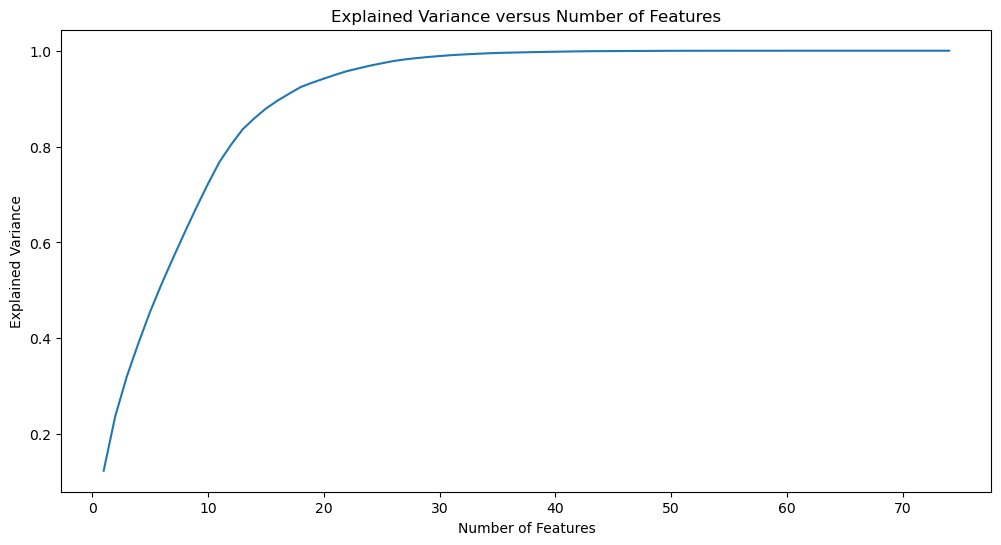

In [45]:
#Instantiate Principal Component Analysis.
pca=PCA()
X_pca = pca.fit_transform(X_trainres)
fig = plt.figure(figsize=(12,6))
plt.plot(range(1,X_trainres.shape[1]+1), pca.explained_variance_ratio_.cumsum())
plt.title('Explained Variance versus Number of Features')
plt.ylabel('Explained Variance')
plt.xlabel('Number of Features')
plt.show();

In [46]:
for n in [10,15,20,25]:
    pca_n = PCA(n_components=n)
    X_pcan = pca_n.fit_transform(X_trainres)
    tev = round(np.sum(pca_n.explained_variance_ratio_)*100,2)
    print('Number of Fetaures: ',n, 'Total Explained Variance: ',tev,'%')

Number of Fetaures:  10 Total Explained Variance:  72.19 %
Number of Fetaures:  15 Total Explained Variance:  87.92 %
Number of Fetaures:  20 Total Explained Variance:  94.17 %
Number of Fetaures:  25 Total Explained Variance:  97.37 %


From this graph I notice that the total explained variace starts to increase at a diminishing rate at around n_components=15. It also reduces dimensionality by a fourth of the size with just above 90% of the total variance explained. I would like the pipelines to try with n_components of 15,20,and 25.


In [47]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X = ohc_data.copy()
y = target.astype(int).ravel()

pipelines = {
    "LR": Pipeline([
        ("scale", StandardScaler(with_mean=False)),   # sparse-friendly if you have many one-hots
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "RF": Pipeline([
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "GB": Pipeline([
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
    "DT": Pipeline([
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])
}

param_grids = {
    "LR": {
        "clf__C": [0.1, 0.5, 1.0, 2.0]
    },
    "RF": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 12, 20],
        "clf__min_samples_leaf": [1, 2]
    },
    "GB": {
        "clf__n_estimators": [150, 250],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3]
    },
    "DT": {
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_split": [2, 10, 50],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__ccp_alpha": [0.0, 1e-3, 1e-2]
    }
}

rows = []
best_models = {}

for name, pipe in pipelines.items():
    grid = GridSearchCV(
        pipe, param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )
    grid.fit(X, y)
    rows.append({
        "model": name,
        "best_roc_auc": grid.best_score_,
        "best_params": grid.best_params_,
    })
    best_models[name] = grid.best_estimator_

pd.DataFrame(rows).sort_values("best_roc_auc", ascending=False)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits


,model,best_roc_auc,best_params
2,GB,0.675647,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
1,RF,0.661556,"{'clf__max_depth': 12, 'clf__min_samples_leaf'..."
3,DT,0.650650,"{'clf__ccp_alpha': 0.0, 'clf__max_depth': 5, '..."
0,LR,0.640205,{'clf__C': 2.0}


From the above, seems like GB family of models wins. Let's obtain the best GradientBoosting pipeline from grid search. We start off by extracting the "best_params" output from the run above (i.e. hyperparameters)

In [48]:
best_params = rows[2]['best_params'] 
print(best_params)

{'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 250}


In [49]:
# ===== Refit best model (GB or XGB) using your existing train/test split =====

# If you want XGBoost instead of GB, set this to "XGB"
MODEL_CHOICE = "GB"   # "GB" or "XGB"


# If your X_train/X_test are already numeric with no NaNs (likely in your notebook),
# set this True to skip any preprocessing pipeline
ALREADY_NUMERIC = True

def strip_clf_prefix(d):
    return {k.split("clf__")[-1]: v for k, v in d.items()}

# ---- Build classifier from pasted params ----
params = strip_clf_prefix(best_params)

if MODEL_CHOICE.upper() == "GB":
    clf = GradientBoostingClassifier(random_state=42, **params)
elif MODEL_CHOICE.upper() == "XGB":
    from xgboost import XGBClassifier
    # make sure eval_metric is set to something stable
    params.setdefault('eval_metric', 'logloss')
    # good defaults if your table didn’t include them:
    params.setdefault('tree_method', 'hist')
    params.setdefault('n_jobs', -1)
    clf = XGBClassifier(random_state=42, **params)
else:
    raise ValueError("MODEL_CHOICE must be 'GB' or 'XGB'.")

# ---- Fit on your existing train split and evaluate on test ----
# (If you needed preprocessing, you could wrap clf in a Pipeline here)
est = clf
est.fit(X_train, y_train)

# Probabilities for threshold-free + thresholded metrics
proba = est.predict_proba(X_test)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X_test)

# Threshold-free
roc = roc_auc_score(y_test, proba)
pra = average_precision_score(y_test, proba)
print(f"{MODEL_CHOICE} | Test ROC-AUC: {roc:.3f} | PR-AUC: {pra:.3f}")

# Best-F1 threshold on the test set (for reporting an operating point)
prec, rec, thr = precision_recall_curve(y_test, proba)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1))
t_best = float(thr[best_idx]) if best_idx < len(thr) else 0.5
print(f"Best-F1 threshold ≈ {t_best:.3f} | F1={f1[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

def metrics_at(t, label):
    pred = (proba >= t).astype(int)
    acc  = accuracy_score(y_test, pred)
    bacc = balanced_accuracy_score(y_test, pred)  # optional but useful for imbalance
    print(f"\nMetrics @ {label}")
    print(f"  Accuracy : {acc:.3f} | Balanced Acc: {bacc:.3f}")
    print(f"  Precision: {precision_score(y_test, pred, zero_division=0):.3f}")
    print(f"  Recall   : {recall_score(y_test, pred):.3f}")
    print(f"  F1       : {f1_score(y_test, pred):.3f}")
    print("  Confusion matrix [[TN, FP], [FN, TP]]:\n", confusion_matrix(y_test, pred))

metrics_at(0.50, "threshold 0.50")
metrics_at(t_best, "best-F1")

final_model = est  # keep for later inference if you like


GB | Test ROC-AUC: 0.679 | PR-AUC: 0.229
Best-F1 threshold ≈ 0.134 | F1=0.282, Precision=0.203, Recall=0.463

Metrics @ threshold 0.50
  Accuracy : 0.889 | Balanced Acc: 0.505
  Precision: 0.567
  Recall   : 0.011
  F1       : 0.022
  Confusion matrix [[TN, FP], [FN, TP]]:
 [[27094    29]
 [ 3369    38]]

Metrics @ best-F1
  Accuracy : 0.737 | Balanced Acc: 0.617
  Precision: 0.203
  Recall   : 0.463
  F1       : 0.282
  Confusion matrix [[TN, FP], [FN, TP]]:
 [[20918  6205]
 [ 1831  1576]]


Let's repeat the gridsearch to tune hyperparameters for various members of the GB family, namely GB, XGB, and LightGBM. We also combine it with stratifiedKFold (5 fold) for cross validation.

In [50]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# handy: class imbalance ratio for pos_weight
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
pos_weight = (neg / pos) if pos > 0 else 1.0

def fit_report(estimator, X_tr, y_tr, X_te, y_te, name="model"):
    est = estimator
    est.fit(X_tr, y_tr)
    proba = est.predict_proba(X_te)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X_te)

    roc = roc_auc_score(y_te, proba)
    pra = average_precision_score(y_te, proba)

    # best-F1 threshold on TEST (you can swap to validation if you prefer)
    p, r, thr = precision_recall_curve(y_te, proba)
    f1s = 2*(p*r)/(p+r+1e-12)
    bi = int(np.nanargmax(f1s))
    t_best = float(thr[bi]) if bi < len(thr) else 0.5

    def dump_at(t, label):
        pred = (proba >= t).astype(int)
        print(f"\n{name} | {label}")
        print(f"  Acc  : {accuracy_score(y_te, pred):.3f}")
        print(f"  Prec : {precision_score(y_te, pred, zero_division=0):.3f}")
        print(f"  Rec  : {recall_score(y_te, pred):.3f}")
        print(f"  F1   : {f1_score(y_te, pred):.3f}")
        print("  CM [[TN FP],[FN TP]]:\n", confusion_matrix(y_te, pred))

    print(f"\n{name} | Test ROC-AUC: {roc:.3f} | PR-AUC: {pra:.3f}")
    dump_at(0.50, "t=0.50")
    dump_at(t_best, f"t=best-F1 ({t_best:.3f})")
    return dict(roc_auc=roc, pr_auc=pra, threshold=t_best)


In [51]:
from collections import Counter
from joblib import parallel_backend #to speed up the algorithms

RANDOM_STATE = 42

# ----- CV splitter -----
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----- class balance numbers & weights -----
cnt = Counter(y_train)
pos = cnt[1]; neg = cnt[0]
pos_weight = neg / max(pos, 1)                # for XGB/LGBM scale_pos_weight arm
sw_balanced = compute_sample_weight('balanced', y_train)  # for GB weighted via sample_weight

results = []

# ========= 1) Gradient Boosting (sklearn) =========
gb_grid = {
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.10, 0.05],
    "clf__max_depth": [3, 5],
}

# (A) baseline (no resampling/weights)
gb_base = ImbPipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
print("GB | baseline (no resampling)")
gs_gb_base = GridSearchCV(gb_base, gb_grid, cv=cv5, scoring="roc_auc",
                          n_jobs=-1, verbose=1)
with parallel_backend('threading'):
    gs_gb_base.fit(X_train, y_train)
results.append(dict(model="GB", strategy="baseline",
                    best_roc_auc=gs_gb_base.best_score_,
                    best_params=gs_gb_base.best_params_))

# (B) weighted via sample_weight at fit()
gb_w = ImbPipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
print("GB | weighted (sample_weight)")
gs_gb_w = GridSearchCV(gb_w, gb_grid, cv=cv5, scoring="roc_auc",
                       n_jobs=-1, verbose=1)
# pass weights through the pipeline step name
with parallel_backend('threading'):
    gs_gb_w.fit(X_train, y_train, **{"clf__sample_weight": sw_balanced})
results.append(dict(model="GB", strategy="weighted(sample_weight)",
                    best_roc_auc=gs_gb_w.best_score_,
                    best_params=gs_gb_w.best_params_))

# (C) SMOTE arm (resample only inside train folds)
gb_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
print("GB | SMOTE")
gs_gb_smote = GridSearchCV(gb_smote, gb_grid, cv=cv5, scoring="roc_auc",
                           n_jobs=-1, verbose=1)  
with parallel_backend('threading'):    
    gs_gb_smote.fit(X_train, y_train)
results.append(dict(model="GB", strategy="SMOTE",
                    best_roc_auc=gs_gb_smote.best_score_,
                    best_params=gs_gb_smote.best_params_))


# ========= 2) XGBoost =========
xgb_common = dict(
    objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE
)

# (A) weighted (scale_pos_weight search)
xgb_base = ImbPipeline([("clf", XGBClassifier(**xgb_common))])
xgb_grid_weight = {
    "clf__n_estimators": [300, 600],
    "clf__learning_rate": [0.10, 0.05],
    "clf__max_depth": [4, 6],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__reg_lambda": [0.0, 1.0],
    "clf__scale_pos_weight": [pos_weight*0.75, pos_weight, pos_weight*1.25],
}
print("XGB | weighted (scale_pos_weight)")
gs_xgb_w = GridSearchCV(xgb_base, xgb_grid_weight, cv=cv5, scoring="roc_auc",
                        n_jobs=-1, verbose=1, error_score='raise')
with parallel_backend('threading'):
    gs_xgb_w.fit(X_train, y_train)
results.append(dict(model="XGB", strategy="weighted",
                    best_roc_auc=gs_xgb_w.best_score_,
                    best_params=gs_xgb_w.best_params_))

# (B) SMOTE arm
xgb_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", XGBClassifier(**xgb_common)),
])
xgb_grid_smote = {
    "clf__n_estimators": [300, 600],
    "clf__learning_rate": [0.10, 0.05],
    "clf__max_depth": [4, 6],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__reg_lambda": [0.0, 1.0],
}
print("XGB | SMOTE")
gs_xgb_smote = GridSearchCV(xgb_smote, xgb_grid_smote, cv=cv5, scoring="roc_auc",
                            n_jobs=-1, verbose=1, error_score='raise')  
with parallel_backend('threading'):    
    gs_xgb_smote.fit(X_train, y_train)
results.append(dict(model="XGB", strategy="SMOTE",
                    best_roc_auc=gs_xgb_smote.best_score_,
                    best_params=gs_xgb_smote.best_params_))


# ========= 3) LightGBM =========
lgb_common = dict(random_state=RANDOM_STATE, n_jobs=1)

# (A) weighted
lgb_base = ImbPipeline([("clf", LGBMClassifier(**lgb_common))])
lgb_grid_weight = {
    "clf__n_estimators": [400, 800],
    "clf__learning_rate": [0.10, 0.05],
    "clf__num_leaves": [31, 63],
    "clf__max_depth": [-1, 8],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__reg_lambda": [0.0, 1.0],
    "clf__scale_pos_weight": [pos_weight*0.75, pos_weight, pos_weight*1.25],
}
print("LGBM | weighted (scale_pos_weight)")
gs_lgb_w = GridSearchCV(lgb_base, lgb_grid_weight, cv=cv5, scoring="roc_auc",
                        n_jobs=-1, verbose=1)
with parallel_backend('threading'):
    gs_lgb_w.fit(X_train, y_train)
results.append(dict(model="LGBM", strategy="weighted",
                    best_roc_auc=gs_lgb_w.best_score_,
                    best_params=gs_lgb_w.best_params_))

# (B) SMOTE arm
lgb_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", LGBMClassifier(**lgb_common)),
])
lgb_grid_smote = {
    "clf__n_estimators": [400, 800],
    "clf__learning_rate": [0.10, 0.05],
    "clf__num_leaves": [31, 63],
    "clf__max_depth": [-1, 8],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__reg_lambda": [0.0, 1.0],
}
print("LGBM | SMOTE")
gs_lgb_smote = GridSearchCV(lgb_smote, lgb_grid_smote, cv=cv5, scoring="roc_auc",
                            n_jobs=-1, verbose=1)  
with parallel_backend('threading'):     
    gs_lgb_smote.fit(X_train, y_train)
results.append(dict(model="LGBM", strategy="SMOTE",
                    best_roc_auc=gs_lgb_smote.best_score_,
                    best_params=gs_lgb_smote.best_params_))

# --- summary table (CV on TRAIN) ---
df_cv = pd.DataFrame(results).sort_values("best_roc_auc", ascending=False).reset_index(drop=True)
display(df_cv)


GB | baseline (no resampling)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GB | weighted (sample_weight)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GB | SMOTE
Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGB | weighted (scale_pos_weight)
Fitting 5 folds for each of 192 candidates, totalling 960 fits
XGB | SMOTE
Fitting 5 folds for each of 64 candidates, totalling 320 fits
LGBM | weighted (scale_pos_weight)
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
[LightGBM] [Info] Number of positive: 7950, number of negative: 63286
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1170
[LightGBM] [Info] Number of data points in the train set: 71236, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111601

,model,strategy,best_roc_auc,best_params
0,XGB,weighted,0.673394,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
1,GB,baseline,0.672576,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
2,GB,weighted(sample_weight),0.669525,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
3,LGBM,weighted,0.666144,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
4,LGBM,SMOTE,0.663141,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
5,GB,SMOTE,0.652593,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
6,XGB,SMOTE,0.651853,"{'clf__colsample_bytree': 1.0, 'clf__learning_..."


Based on ROC_AUC, XGB weighted is the winner, althought it is very close. Let's obtain its metrics and confusion matrix.

In [52]:


# --- 1) Pull the best XGB pipeline from your grid search and (re)fit on full training data
best_params = gs_xgb_w.best_params_
print("Best XGB (weighted) params from CV:\n", best_params)

best_xgb_pipe = gs_xgb_w.best_estimator_   # already refit=True by default, but we refit explicitly to be safe
best_xgb_pipe.fit(X_train, y_train)

# --- 2) Predict probabilities on the held-out test set
proba = best_xgb_pipe.predict_proba(X_test)[:, 1]

# Threshold-free metrics
roc = roc_auc_score(y_test, proba)
pr  = average_precision_score(y_test, proba)  # PR-AUC (a.k.a. Average Precision)

# --- 3) Metrics at threshold=0.50
pred_05 = (proba >= 0.50).astype(int)
acc_05  = accuracy_score(y_test, pred_05)
f1_05   = f1_score(y_test, pred_05)
prec_05 = precision_score(y_test, pred_05, zero_division=0)
rec_05  = recall_score(y_test, pred_05)
cm_05   = confusion_matrix(y_test, pred_05)  # [[TN, FP],[FN, TP]]

# --- 4) Find the single threshold that maximizes F1 on the test set
p, r, thr = precision_recall_curve(y_test, proba)        # thr has length len(p)-1
f1_curve = 2 * (p * r) / (p + r + 1e-12)
i_best = int(np.nanargmax(f1_curve[:-1]))                # ignore the last point (no threshold)
t_best = float(thr[i_best])

pred_b = (proba >= t_best).astype(int)
acc_b  = accuracy_score(y_test, pred_b)
f1_b   = f1_score(y_test, pred_b)
prec_b = precision_score(y_test, pred_b, zero_division=0)
rec_b  = recall_score(y_test, pred_b)
cm_b   = confusion_matrix(y_test, pred_b)

# --- 5) Print a compact report
print(f"\nXGB (weighted) — Test ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f}")
print(f"Best-F1 threshold ≈ {t_best:.3f}")

print("\nMetrics @ threshold 0.50")
print(f"  Accuracy : {acc_05:.3f}")
print(f"  Precision: {prec_05:.3f}")
print(f"  Recall   : {rec_05:.3f}")
print(f"  F1       : {f1_05:.3f}")
print("  Confusion matrix [ [TN, FP], [FN, TP] ]:\n", cm_05)

print("\nMetrics @ best-F1")
print(f"  Accuracy : {acc_b:.3f}")
print(f"  Precision: {prec_b:.3f}")
print(f"  Recall   : {rec_b:.3f}")
print(f"  F1       : {f1_b:.3f}")
print("  Confusion matrix [ [TN, FP], [FN, TP] ]:\n", cm_b)


Best XGB (weighted) params from CV:
 {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'clf__reg_lambda': 1.0, 'clf__scale_pos_weight': 5.970377358490566, 'clf__subsample': 0.8}

XGB (weighted) — Test ROC-AUC: 0.680 | PR-AUC: 0.232
Best-F1 threshold ≈ 0.490

Metrics @ threshold 0.50
  Accuracy : 0.768
  Precision: 0.214
  Recall   : 0.404
  F1       : 0.280
  Confusion matrix [ [TN, FP], [FN, TP] ]:
 [[22068  5055]
 [ 2032  1375]]

Metrics @ best-F1
  Accuracy : 0.755
  Precision: 0.210
  Recall   : 0.433
  F1       : 0.283
  Confusion matrix [ [TN, FP], [FN, TP] ]:
 [[21564  5559]
 [ 1932  1475]]


As a bonus we can also look at the metrics and confusion matrices of the other GB related algorithms

In [53]:

# ---- helpers ----
def get_proba(estimator, X):
    """Return positive-class probabilities, falling back to decision_function if needed."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, "decision_function"):
        # rescale decision scores to 0..1 with a logistic map
        s = estimator.decision_function(X).astype(float)
        return 1 / (1 + np.exp(-s))
    else:
        raise ValueError("Estimator has neither predict_proba nor decision_function.")

def best_f1_threshold(y_true, proba):
    p, r, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * (p * r) / (p + r + 1e-12)
    i = int(np.nanargmax(f1))
    t = float(thr[i]) if i < len(thr) else 0.5
    return t

def eval_at_threshold(y_true, proba, t):
    pred = (proba >= t).astype(int)
    return dict(
        threshold=t,
        accuracy=accuracy_score(y_true, pred),
        precision=precision_score(y_true, pred, zero_division=0),
        recall=recall_score(y_true, pred, zero_division=0),
        f1=f1_score(y_true, pred)
    )

# ---- which fitted models to score ----
# Uses the best estimators from your earlier GridSearchCV runs.
# Make sure these objects exist from your CV cell:
#   gs_xgb_w, gs_gb_base, gs_gb_w, gs_lgb_w, gs_lgb_smote, gs_xgb_smote, gs_gb_smote
to_score = [
    ("XGB (weighted)",       gs_xgb_w.best_estimator_),
    ("GB  (baseline)",       gs_gb_base.best_estimator_),
    ("GB  (weighted)",       gs_gb_w.best_estimator_),
    ("LGBM (weighted)",      gs_lgb_w.best_estimator_),
    ("LGBM (SMOTE)",         gs_lgb_smote.best_estimator_),
    ("XGB (SMOTE)",          gs_xgb_smote.best_estimator_),
    ("GB  (SMOTE)",          gs_gb_smote.best_estimator_),
]

rows = []
for name, est in to_score:
    # if your GridSearchCV used refit=True (default), these are already trained on X_train
    proba = get_proba(est, X_test)

    # metrics @ 0.50
    m50 = eval_at_threshold(y_test, proba, 0.50)
    rows.append(dict(model=name, which="@0.50", **m50))

    # metrics @ best-F1
    t_best = best_f1_threshold(y_test, proba)
    mb  = eval_at_threshold(y_test, proba, t_best)
    rows.append(dict(model=name, which="@best-F1", **mb))

# tidy table
df_metrics = (pd.DataFrame(rows)
              .sort_values(["model","which"])
              .reset_index(drop=True))
display(df_metrics)

# (Optional) pretty print per model
for name in df_metrics["model"].unique():
    sub = df_metrics[df_metrics.model == name]
    print(f"\n{name}")
    for _, r in sub.iterrows():
        print(f"  {r['which']}: thr={r['threshold']:.3f} | "
              f"Acc={r['accuracy']:.3f}  Prec={r['precision']:.3f}  "
              f"Rec={r['recall']:.3f}  F1={r['f1']:.3f}")


,model,which,threshold,accuracy,precision,recall,f1
0,GB (SMOTE),@0.50,0.500000,0.888536,0.514286,0.021133,0.040598
1,GB (SMOTE),@best-F1,0.167383,0.736718,0.195609,0.436748,0.270202
2,GB (baseline),@0.50,0.500000,0.888634,0.539326,0.014089,0.027460
3,GB (baseline),@best-F1,0.132136,0.728071,0.199435,0.476666,0.281212
4,GB (weighted),@0.50,0.500000,0.643465,0.176389,0.598180,0.272442
5,GB (weighted),@best-F1,0.573199,0.774222,0.218235,0.396243,0.281455
6,LGBM (SMOTE),@0.50,0.500000,0.888896,0.563025,0.019665,0.038003
7,LGBM (SMOTE),@best-F1,0.132313,0.672912,0.186146,0.572645,0.280962
8,LGBM (weighted),@0.50,0.500000,0.779201,0.219455,0.382741,0.278960
9,LGBM (weighted),@best-F1,0.487465,0.764821,0.214815,0.417082,0.283576



GB  (SMOTE)
  @0.50: thr=0.500 | Acc=0.889  Prec=0.514  Rec=0.021  F1=0.041
  @best-F1: thr=0.167 | Acc=0.737  Prec=0.196  Rec=0.437  F1=0.270

GB  (baseline)
  @0.50: thr=0.500 | Acc=0.889  Prec=0.539  Rec=0.014  F1=0.027
  @best-F1: thr=0.132 | Acc=0.728  Prec=0.199  Rec=0.477  F1=0.281

GB  (weighted)
  @0.50: thr=0.500 | Acc=0.643  Prec=0.176  Rec=0.598  F1=0.272
  @best-F1: thr=0.573 | Acc=0.774  Prec=0.218  Rec=0.396  F1=0.281

LGBM (SMOTE)
  @0.50: thr=0.500 | Acc=0.889  Prec=0.563  Rec=0.020  F1=0.038
  @best-F1: thr=0.132 | Acc=0.673  Prec=0.186  Rec=0.573  F1=0.281

LGBM (weighted)
  @0.50: thr=0.500 | Acc=0.779  Prec=0.219  Rec=0.383  F1=0.279
  @best-F1: thr=0.487 | Acc=0.765  Prec=0.215  Rec=0.417  F1=0.284

XGB (SMOTE)
  @0.50: thr=0.500 | Acc=0.889  Prec=0.604  Rec=0.026  F1=0.049
  @best-F1: thr=0.158 | Acc=0.751  Prec=0.208  Rec=0.437  F1=0.282

XGB (weighted)
  @0.50: thr=0.500 | Acc=0.768  Prec=0.214  Rec=0.404  F1=0.280
  @best-F1: thr=0.490 | Acc=0.755  Prec=0.210

In [54]:
# --- tiny helpers (safe to re-run if already defined) ---
def get_proba(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, "decision_function"):
        s = estimator.decision_function(X).astype(float)
        return 1 / (1 + np.exp(-s))
    else:
        raise ValueError("Estimator has neither predict_proba nor decision_function.")

def best_f1_threshold(y_true, proba):
    p, r, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * (p * r) / (p + r + 1e-12)
    i = int(np.nanargmax(f1))
    return float(thr[i]) if i < len(thr) else 0.5

def print_cm(cm, title):
    tn, fp, fn, tp = cm.ravel()
    print(title)
    print("  [[TN, FP],")
    print("   [FN, TP]]")
    print(f"  [[{tn:5d}, {fp:5d}],")
    print(f"   [{fn:5d}, {tp:5d}]]\n")

# ---- which fitted models to score (from your GridSearchCV objects) ----
to_score = [
    ("XGB (weighted)",       gs_xgb_w.best_estimator_),
    ("GB  (baseline)",       gs_gb_base.best_estimator_),
    ("GB  (weighted)",       gs_gb_w.best_estimator_),
    ("LGBM (weighted)",      gs_lgb_w.best_estimator_),
    ("LGBM (SMOTE)",         gs_lgb_smote.best_estimator_),
    ("XGB (SMOTE)",          gs_xgb_smote.best_estimator_),
    ("GB  (SMOTE)",          gs_gb_smote.best_estimator_),
]

for name, est in to_score:
    proba = get_proba(est, X_test)

    # --- @ 0.50 ---
    pred50 = (proba >= 0.50).astype(int)
    cm50   = confusion_matrix(y_test, pred50, labels=[0, 1])
    cm50n  = confusion_matrix(y_test, pred50, labels=[0, 1], normalize='true')  # row-normalized

    # --- @ best-F1 ---
    t_best = best_f1_threshold(y_test, proba)
    predb  = (proba >= t_best).astype(int)
    cmb    = confusion_matrix(y_test, predb, labels=[0, 1])
    cmbn   = confusion_matrix(y_test, predb, labels=[0, 1], normalize='true')

    print(f"\n=== {name} ===")
    print_cm(cm50,  "Confusion matrix @ 0.50")
    print("Row-normalized @ 0.50 (rows = true class [0,1]):")
    print(np.round(cm50n, 3), "\n")

    print_cm(cmb,   f"Confusion matrix @ best-F1 (t≈{t_best:.3f})")
    print("Row-normalized @ best-F1 (rows = true class [0,1]):")
    print(np.round(cmbn, 3))



=== XGB (weighted) ===
Confusion matrix @ 0.50
  [[TN, FP],
   [FN, TP]]
  [[22068,  5055],
   [ 2032,  1375]]

Row-normalized @ 0.50 (rows = true class [0,1]):
[[0.814 0.186]
 [0.596 0.404]] 

Confusion matrix @ best-F1 (t≈0.490)
  [[TN, FP],
   [FN, TP]]
  [[21564,  5559],
   [ 1932,  1475]]

Row-normalized @ best-F1 (rows = true class [0,1]):
[[0.795 0.205]
 [0.567 0.433]]

=== GB  (baseline) ===
Confusion matrix @ 0.50
  [[TN, FP],
   [FN, TP]]
  [[27082,    41],
   [ 3359,    48]]

Row-normalized @ 0.50 (rows = true class [0,1]):
[[0.998 0.002]
 [0.986 0.014]] 

Confusion matrix @ best-F1 (t≈0.132)
  [[TN, FP],
   [FN, TP]]
  [[20604,  6519],
   [ 1783,  1624]]

Row-normalized @ best-F1 (rows = true class [0,1]):
[[0.76  0.24 ]
 [0.523 0.477]]

=== GB  (weighted) ===
Confusion matrix @ 0.50
  [[TN, FP],
   [FN, TP]]
  [[17607,  9516],
   [ 1369,  2038]]

Row-normalized @ 0.50 (rows = true class [0,1]):
[[0.649 0.351]
 [0.402 0.598]] 

Confusion matrix @ best-F1 (t≈0.573)
  [[TN, 

If you judge by accuracy, XGB SMOTE at threshold of 0.5 wins. Let's perform SHAP analysis on XGB SMOTE and XGB weighted to look at the features that affect results the most.

100%|===================| 30473/30530 [02:35<00:00]        

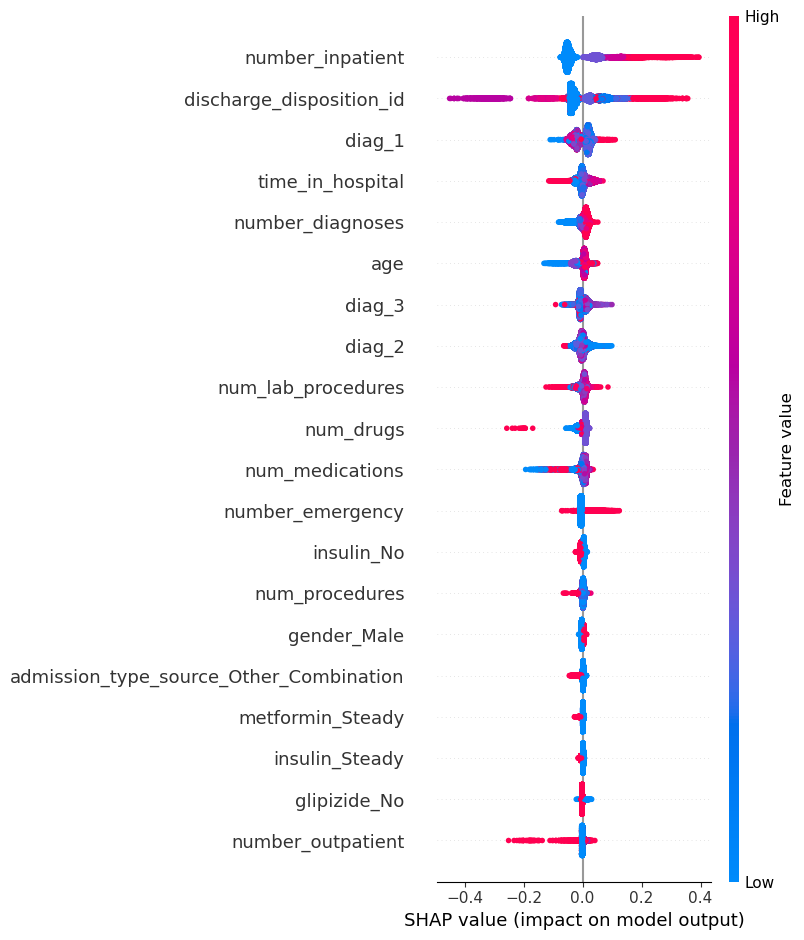

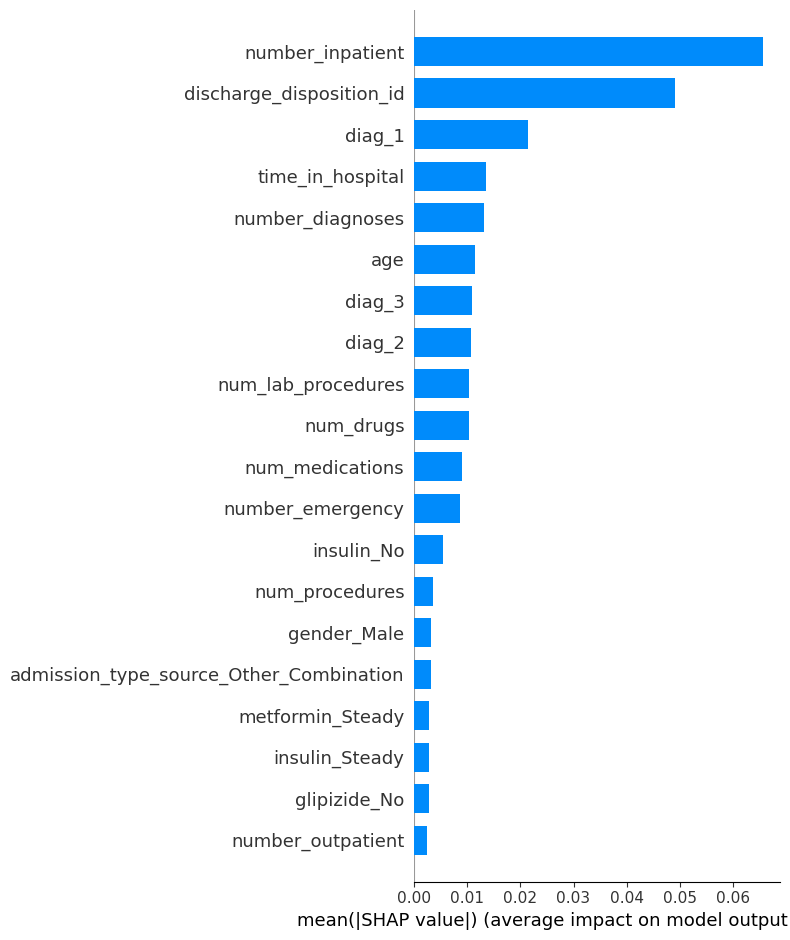

In [59]:
import shap

# 1) pull the fitted classifier from your GridSearch pipeline
#    (this assumes you kept the variables from the earlier cell)
xgb_w = gs_xgb_w.best_estimator_
xgb_w_clf = xgb_w.named_steps['clf']  # the XGBClassifier itself

# 2) build numeric background & eval matrices with the **same columns & order** as training
def numeric_matrix(df_like, feature_names):
    # select in the model's feature order and coerce to float32 ndarray
    if hasattr(df_like, "loc"):
        X = df_like.loc[:, feature_names]
        # if any column is object, try to coerce
        if any(X.dtypes == "object"):
            X = X.apply(pd.to_numeric, errors="coerce")
    else:
        # already an array
        X = pd.DataFrame(df_like, columns=feature_names)
    # fill any NaNs that could arise from coercion (tree models handle a constant fine)
    X = X.fillna(0.0)
    return X.to_numpy(dtype=np.float32)

# figure out the exact feature names the model saw at fit
if hasattr(xgb_w_clf, "feature_names_in_"):
    feat_names = list(xgb_w_clf.feature_names_in_)
else:
    # fallback: assume current X_train columns are the training features
    feat_names = list(X_train.columns)

# small background sample for speed
bg_idx = np.random.RandomState(42).choice(len(X_train), size=min(256, len(X_train)), replace=False)
X_bg = numeric_matrix(X_train.iloc[bg_idx], feat_names)
X_ex = numeric_matrix(X_test, feat_names)   # explain the whole test set (you can slice for speed)

# 3) build explainer & compute SHAP (probabilities for binary classifier)
explainer_w = shap.TreeExplainer(xgb_w_clf, data=X_bg, model_output="probability", feature_perturbation="interventional")
# For new SHAP versions you can also do: explainer_w = shap.Explainer(xgb_w_clf, X_bg, algorithm="tree")
shap_vals_w = explainer_w.shap_values(X_ex, check_additivity=False)

# 4) plots — top-20 global importances
#    Use the same feature names for readability
plt.figure()
shap.summary_plot(shap_vals_w, features=X_ex, feature_names=feat_names, max_display=20, show=True)

plt.figure()
shap.summary_plot(shap_vals_w, features=X_ex, feature_names=feat_names, max_display=20, plot_type="bar", show=True)


100%|===================| 30502/30530 [12:07<00:00]        

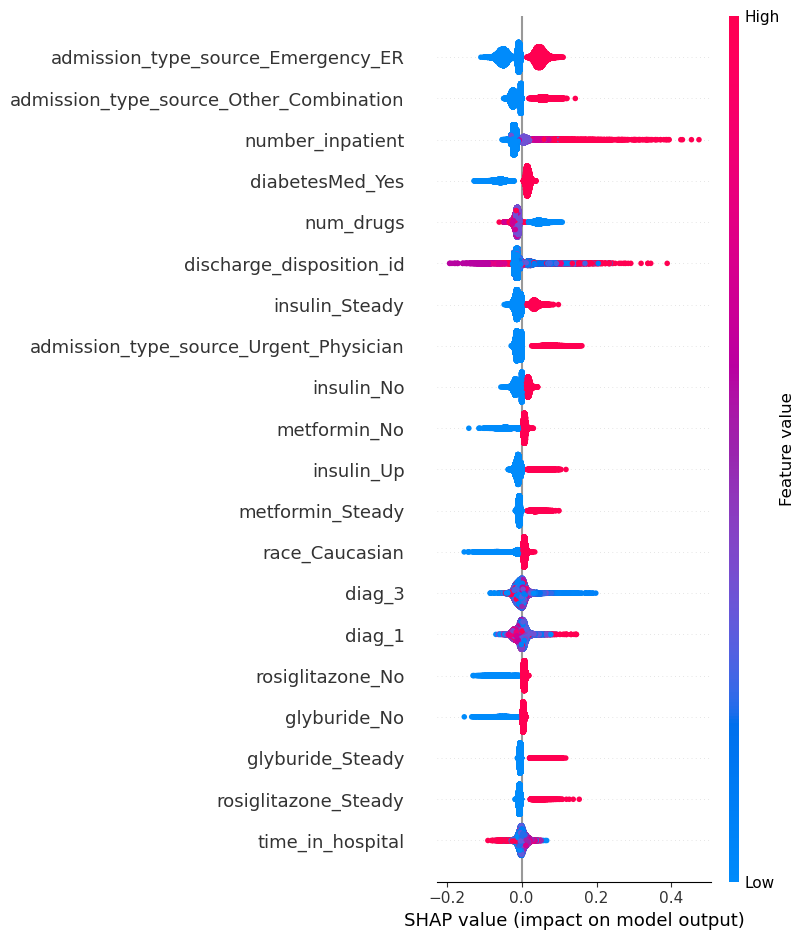

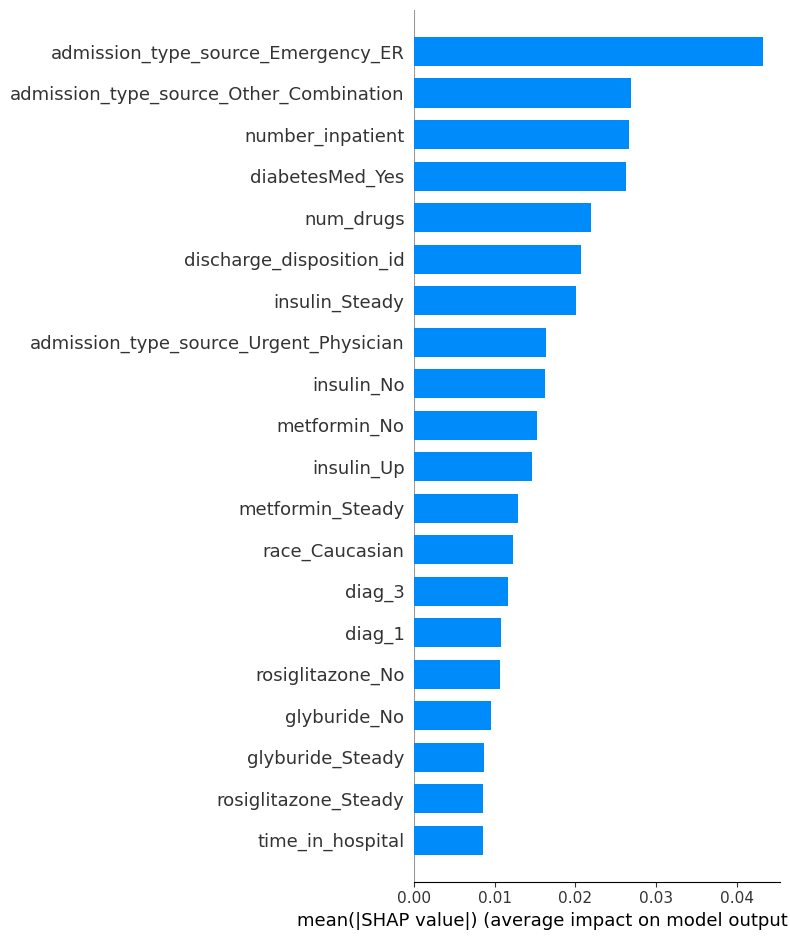

In [60]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1) pull the fitted classifier from the SMOTE GridSearch pipeline
xgb_s = gs_xgb_smote.best_estimator_
xgb_s_clf = xgb_s.named_steps['clf']  # the XGBClassifier itself

# 2) build numeric background & eval matrices with the **same columns & order** as training
def numeric_matrix(df_like, feature_names):
    if hasattr(df_like, "loc"):
        X = df_like.loc[:, feature_names]
        if any(X.dtypes == "object"):
            X = X.apply(pd.to_numeric, errors="coerce")
    else:
        X = pd.DataFrame(df_like, columns=feature_names)
    X = X.fillna(0.0)
    return X.to_numpy(dtype=np.float32)

if hasattr(xgb_s_clf, "feature_names_in_"):
    feat_names = list(xgb_s_clf.feature_names_in_)
else:
    feat_names = list(X_train.columns)

bg_idx = np.random.RandomState(42).choice(len(X_train), size=min(256, len(X_train)), replace=False)
X_bg = numeric_matrix(X_train.iloc[bg_idx], feat_names)
X_ex = numeric_matrix(X_test, feat_names)

# 3) explainer & SHAP values
explainer_s = shap.TreeExplainer(xgb_s_clf, data=X_bg, model_output="probability", feature_perturbation="interventional")
shap_vals_s = explainer_s.shap_values(X_ex, check_additivity=False)

# 4) plots — top-20 global importances
plt.figure()
shap.summary_plot(shap_vals_s, features=X_ex, feature_names=feat_names, max_display=20, show=True)

plt.figure()
shap.summary_plot(shap_vals_s, features=X_ex, feature_names=feat_names, max_display=20, plot_type="bar", show=True)

## 5. Classification Models

Now that the data is prepped for modelling I will start by creating pipelines with grid search to tune the hyperparameters of each of the models. 

In [61]:
'''
#Create pipeline for each of the classifiers.
pipelines = {'logisticregression': Pipeline([('pca', PCA()),
                                            ('clf', LogisticRegression(random_state=123))]),
            'decisiontree':Pipeline([('pca', PCA()),
                                            ('clf', DecisionTreeClassifier(random_state=123))]),
            'randomforest':Pipeline([('pca', PCA()),
                                            ('clf', RandomForestClassifier(random_state=123))]),
            'gradientboosting': Pipeline([('pca', PCA()),
                                            ('clf', GradientBoostingClassifier(random_state=123))])}

#Define Hyperparameters for each pipeline
hyperparameters_lr ={'pca__n_components': [15, 20, 25],
                     'clf__C': [0.01,0.1,1]}

hyperparameters_dt ={'pca__n_components': [10, 15, 20],
                     'clf__criterion': ['entropy', 'gini'], 
                     'clf__max_depth': [4, 5, 6],  
                     'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
                     'clf__min_samples_split':[0.05 ,0.1, 0.2]}

hyperparameters_rf ={'pca__n_components': [10, 15, 20],
                     'clf__n_estimators': [100,150],
                     'clf__criterion': ['entropy', 'gini'], 
                     'clf__max_depth': [4, 5, 6],  
                     'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
                     'clf__min_samples_split':[0.05 ,0.1, 0.2]}

hyperparameters_gb ={'pca__n_components': [10, 15, 20],
                     'clf__n_estimators': [100,150], 
                     'clf__max_depth': [1, 3, 5],  
                     'clf__learning_rate': [0.05,0.1]}

#Instantiate hyperparapeter dictionary
hyperparameters = {'logisticregression':hyperparameters_lr ,
                   'decisiontree':hyperparameters_dt,
                   'randomforest':hyperparameters_rf,
                   'gradientboosting': hyperparameters_gb}
'''

"\n#Create pipeline for each of the classifiers.\npipelines = {'logisticregression': Pipeline([('pca', PCA()),\n                                            ('clf', LogisticRegression(random_state=123))]),\n            'decisiontree':Pipeline([('pca', PCA()),\n                                            ('clf', DecisionTreeClassifier(random_state=123))]),\n            'randomforest':Pipeline([('pca', PCA()),\n                                            ('clf', RandomForestClassifier(random_state=123))]),\n            'gradientboosting': Pipeline([('pca', PCA()),\n                                            ('clf', GradientBoostingClassifier(random_state=123))])}\n\n#Define Hyperparameters for each pipeline\nhyperparameters_lr ={'pca__n_components': [15, 20, 25],\n                     'clf__C': [0.01,0.1,1]}\n\nhyperparameters_dt ={'pca__n_components': [10, 15, 20],\n                     'clf__criterion': ['entropy', 'gini'], \n                     'clf__max_depth': [4, 5, 6],  \n       

In [62]:
#model_scores_auc, fitted_models_auc = grid_pipe(pipelines,hyperparameters,scoring='roc_auc')

In [63]:
#score_times_df_auc = pd.DataFrame(model_scores_auc,
                           #   columns=['classifier','roc_auc_score',
                                      # 'time']).set_index('classifier').sort_values('time')
#score_times_df_auc

The best performing classifier is gradient boosting with almost 95% roc_auc score. It is expected that ensemble models perform better than single classifiers. However, this comes at greater computational cost. The second best performing model is also an ensemble model, random forest, but given it almost identical score to logistic regression and that it took close to 100 times more time to fit, I consider the second best model to be logistic regression.

In [64]:
#for name, model in fitted_models_auc.items():
    #if name in ['logisticregression','gradientboosting']:
       # pred = model.predict(X_test)
       # print(name,':')
       # plot_confusion_matrix_from_data(y_test,pred, columns=['Non-Revenue','Revenue'], cmap='Oranges')

In [65]:
#model_scores_f1, fitted_models_f1 = grid_pipe(pipelines,hyperparameters,scoring='f1')

In [66]:
#score_times_df_f1 = pd.DataFrame(model_scores_f1,
                             # columns=['classifier','f1_score',
                                      # 'time']).set_index('classifier').sort_values('time')
#score_times_df_f1

In [67]:
#for name, model in fitted_models_f1.items():
    #if name in ['logisticregression','gradientboosting']:
       # pred = model.predict(X_test)
       # print(name,':')
        #plot_confusion_matrix_from_data(y_test,pred,columns=['Non-Revenue','Revenue'], cmap='Oranges')

In [68]:
#fitted_models_f1['gradientboosting'].best_params_

## 6. Conclusion and Recommendations
At first, I looked into the f1 score in order to improve the balnce of the imbalanced dataset. I checked for multicolinearity and delt with high correletaion features accordingly. The f1 score increase by about 6% and the roc_auc score by 8% just through scrubbing the data.

Once the data was ready to enter the pipelines to perform hyperparameter tuning, I conducted principal component analysis to derive the best n_component values to pass on to the pipelines. Turns out the with n_components =25 the data contains a little over 96% of the total explained variance, with half the number of total features. And, with n_components =15, the dataset contains over 90% of the total explained variance. So, decided to imput values in that range.

After running the grid search pipeline, the two best performing models are gradient boosting and logistic regression. Gradient boosting surpasses logistic regression in every metric, except running time. Hence, it will be important to consider the trade-off between computational cost and time.

In , my opinion, I recommend to test the Gradient Boosting Classifier in server conditions. If the model takes a long time to make the classiification, then Logistic Regression is preferred. Identification of the class of session as the user navigates the website has to be immediate in order to deploy marketing tactics that incentivize revenue generating behaviour being carefull not to be a deterrant. If the user is exhibiting favorable behaviour there is no need for aggresive tactics that could scare him.

In [69]:
#score_times_df_f1.loc[['gradientboosting','logisticregression']]

In [70]:
#score_times_df_auc.loc[['gradientboosting','logisticregression']]

## 7 Further Work
In order to keep improving the model, this are the following actionable steps:
+ Try a different SMOTE sampling startegy that resust in a different target incidency.
+ Create duartion per page for Administrative and Informative related pages.
+ Create a new pipeline with only logistic regressor and gradient boosting classifier and try other different parameters that approximate the pipe's resulting best parameters.

## 8. Bibliography and References
* Dataset: Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). https://link.springer.com/article/10.1007%2Fs00521-018-3523-0